In [ ]:
%pip install pyspark
%pip install panel
%pip install jupyter_bokeh
%pip install PyArrow

In [17]:
import pyspark
pyspark.__version__
import panel as pn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pn.extension()
import os
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("pyspark_treino").getOrCreate()

In [5]:
g_raw = spark.read.csv("data/HISTORICO.csv", header=True, inferSchema=True)
g_raw.show(5)
g_raw.printSchema()

+-------------------+-------------------+------------------------+---------+------------------+----------------------+---------------+---------------------+----------------------+----------------------+-----------------------+---------------------+------------------------------+------------------------------+
|               time|temperature_2m (°C)|relative_humidity_2m (%)|rain (mm)|pressure_msl (hPa)|surface_pressure (hPa)|cloud_cover (%)|wind_speed_10m (km/h)|wind_speed_100m (km/h)|wind_direction_10m (°)|wind_direction_100m (°)|wind_gusts_10m (km/h)|soil_temperature_0_to_7cm (°C)|soil_moisture_0_to_7cm (m³/m³)|
+-------------------+-------------------+------------------------+---------+------------------+----------------------+---------------+---------------------+----------------------+----------------------+-----------------------+---------------------+------------------------------+------------------------------+
|2010-01-01 00:00:00|               22.5|                      28| 

In [33]:
from pyspark.sql.window import Window
from pyspark.sql.functions import udf, row_number
from pyspark.sql.types import DoubleType

g_temp               = g_raw
datas                = [row['time'] for row in g_temp.select("time").collect()]
month                = [date.month for date in datas]
normalizar_mes       = udf(lambda m: (m.month - 1) / 11 - 0.5, DoubleType())

g_temp = g_temp.withColumn("month", normalizar_mes(g_temp['time']))
g_temp = g_temp.withColumn("indice", row_number().over(Window.partitionBy("month").orderBy("time")) - 1)
g_temp = g_temp.withColumnsRenamed({'temperature_2m (°C)' : 'temp', 'soil_temperature_0_to_7cm (°C)' : 'soil_temp'})
g_temp = g_temp.select('indice', 'month', 'temp', 'soil_temp')

#display the 1st five rows with panel, hide the index column
pn.widgets.DataFrame(g_temp.limit(5).toPandas().drop(columns=['indice']), width=800)


BokehModel(combine_events=True, render_bundle={'docs_json': {'11f7e124-ccba-4f6b-9f50-5f15434184d5': {'version…

In [29]:
import random
pn.widgets.DataFrame(pd.DataFrame({
		''    : ['Sample 0','Sample 1', 'Sample 1', 'Sample 3', 'Sample 4'],
		't₋₂ (temp)' : [random.uniform(-0.5, 0.5) for _ in range(5)],
		't₋₁ (temp)'  : [random.uniform(-0.5, 0.5) for _ in range(5)],
		't₀  (temp)' : [random.uniform(-0.5, 0.5) for _ in range(5)]
    }), width=800, show_index=False)

BokehModel(combine_events=True, render_bundle={'docs_json': {'1c4f4c45-6dc8-4491-a3e1-6784a55a6a80': {'version…

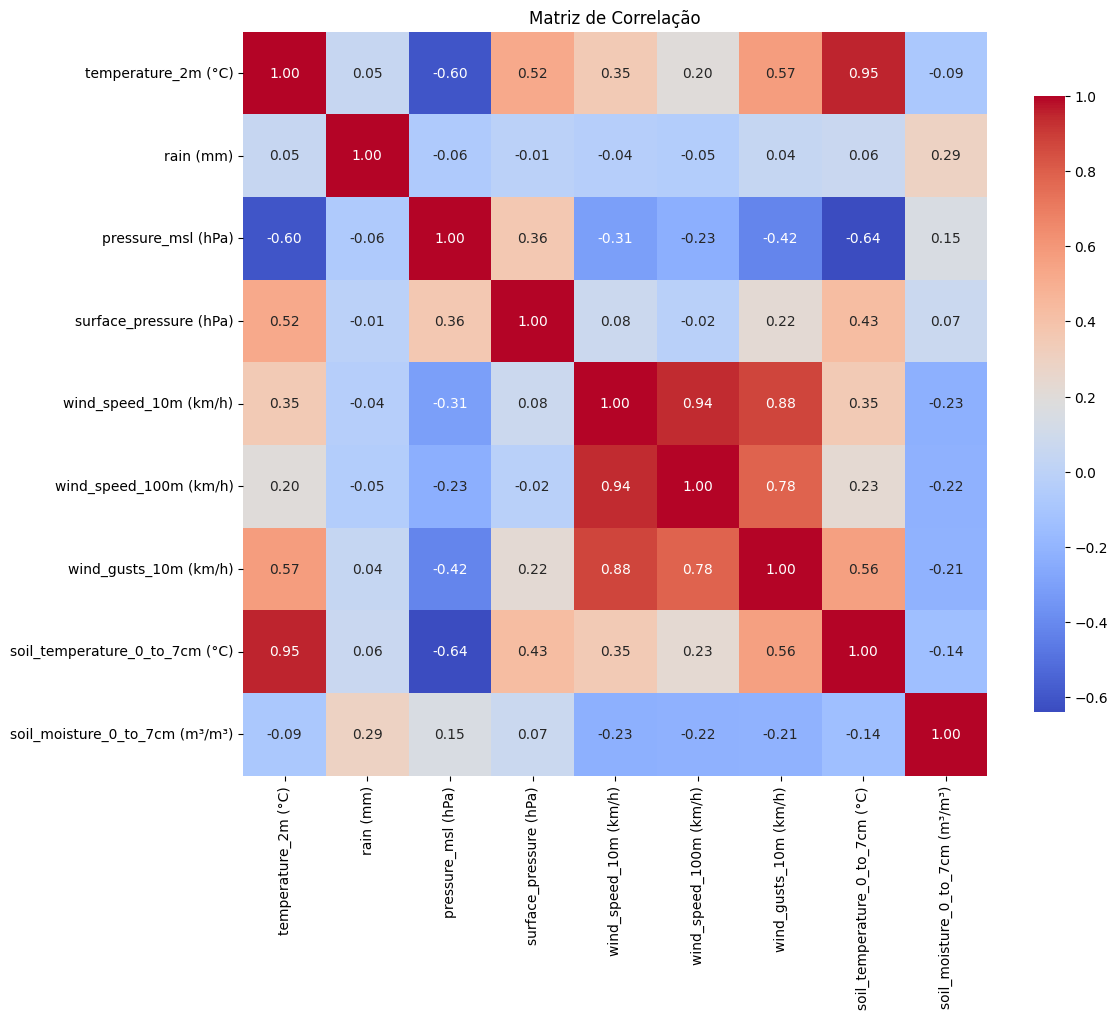

+-------------------+------------------------------+-------------------+
|temperature_2m (°C)|soil_temperature_0_to_7cm (°C)|               time|
+-------------------+------------------------------+-------------------+
|               22.5|                          23.4|2010-01-01 00:00:00|
|               21.0|                          21.2|2010-01-01 01:00:00|
|               19.7|                          19.6|2010-01-01 02:00:00|
|               18.2|                          18.2|2010-01-01 03:00:00|
|               16.8|                          17.1|2010-01-01 04:00:00|
+-------------------+------------------------------+-------------------+
only showing top 5 rows


In [35]:
def MatrizDeCorrelacao(df):
	import pandas as pd
	import seaborn as sns
	import matplotlib.pyplot as plt
	numeric_df = df.select([column for column, dtype in df.dtypes if dtype == 'double'])
	pandas_df  = numeric_df.toPandas()
	corr       = pandas_df.corr()
	plt.figure(figsize=(12, 10))
	sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
	plt.title('Matriz de Correlação')
	plt.show()

	# retornar apenas temperature_2m (°C) soil_temperature_0_to_7cm (°C) e timestamp
	filtered_df = df.select("temperature_2m (°C)", "soil_temperature_0_to_7cm (°C)", "time")
	return filtered_df

g_features = MatrizDeCorrelacao(g_raw) 
g_features.show(5)

In [37]:
from bokeh.plotting import figure
import panel as pn
import pandas as pd

def Reamostrar(df):

	def __Reamostrar(df, freq='W'):
		import pyspark.pandas as ps
		from pyspark.sql import SparkSession    
		df          = df.toPandas()
		df['time']  = pd.to_datetime(df['time'])
		df          = df.set_index('time').sort_index()
		reamostrado = df.resample(freq).mean()
		reamostrado = reamostrado.reset_index()
		return spark.createDataFrame(reamostrado)

	reamostrado_diario = __Reamostrar(g_features)

	def DecomporTemp(df, column):
		from statsmodels.tsa.seasonal import seasonal_decompose   
		raw_decomposition_year = seasonal_decompose(df[column], model='additive', period=8766)
		raw_decomposition_day  = seasonal_decompose(df[column], model='additive', period=24)
		return raw_decomposition_year, raw_decomposition_day

	def DecomporTempDiario(df, column):
		from statsmodels.tsa.seasonal import seasonal_decompose
		# Para dados diários, use period=365 (ano) e period=7 (semana)
		decomp_ano = seasonal_decompose(df[column], model='additive', period=52)		
		return decomp_ano

	# Seleciona apenas 4 anos do DataFrame
	anual_pd         = df.toPandas()
	anual_pd['time'] = pd.to_datetime(anual_pd['time'])
	anual_pd         = anual_pd.set_index('time').sort_index()
	quatro_anos      = anual_pd.iloc[:4*8766]  # 4 anos * 8766 horas/ano

	anual_decomp, daily_decomp = DecomporTemp(quatro_anos, "temperature_2m (°C)")

	# Decomposição do reamostrado diário
	reamostrado_pd         = reamostrado_diario.toPandas()
	reamostrado_pd['time'] = pd.to_datetime(reamostrado_pd['time'])
	reamostrado_pd         = reamostrado_pd.set_index('time').sort_index()
	reamostrado_decomp_ano = DecomporTempDiario(reamostrado_pd, "temperature_2m (°C)")

	def plot_all_components(decomp, title_prefix, show_seasonal_full=True):
		plots = []
		cores = {'trend': 'blue', 'seasonal': 'green', 'resid': 'red'}
		for comp in ['trend', 'seasonal', 'resid']:
			p = figure(width=600, height=200, title=f"{title_prefix} - {comp.capitalize()}")
			y = decomp.__getattribute__(comp).values
			x = decomp.__getattribute__(comp).index
			# Para a decomposição diária, mostra apenas 10 dias do componente seasonal
			if (title_prefix == "Diária") and (comp == "seasonal") and not show_seasonal_full:
				y = y[:24*10]
				x = x[:24*10]
			p.line(x, y, line_width=2, color=cores[comp])
			p.xaxis.axis_label = "Tempo"
			p.yaxis.axis_label = "Temperatura (°C)"
			plots.append(p)
		return pn.Column(*plots)

	tabs = pn.Tabs(
		("Anual", plot_all_components(anual_decomp, "Anual")),
		("Diária", plot_all_components(daily_decomp, "Diária", show_seasonal_full=False)),
		("Decomposição Reamostrado Diário (Ano)", plot_all_components(reamostrado_decomp_ano, "Reamostrado Diário - Ano"))
	)

	return tabs, reamostrado_diario
from pyspark.sql.window import Window
from pyspark.sql.functions import udf, row_number
from pyspark.sql.types import DoubleType
tabs, g_reamostrado_diario = Reamostrar(g_features) 
datas                = [row['time'] for row in g_reamostrado_diario.select("time").collect()]
month                = [date.month for date in datas]
normalizar_mes       = udf(lambda m: (m.month - 1) / 11 - 0.5, DoubleType())
g_reamostrado_diario = g_reamostrado_diario.withColumn("month", normalizar_mes(g_reamostrado_diario['time']))
g_reamostrado_diario = g_reamostrado_diario.withColumn("indice", row_number().over(Window.partitionBy("month").orderBy("time")) - 1)
g_reamostrado_diario = g_reamostrado_diario.withColumnsRenamed({'temperature_2m (°C)' : 'temp', 'soil_temperature_0_to_7cm (°C)' : 'soil_temp'})
g_reamostrado_diario.show(5)	
g_reamostrado_diario.write.partitionBy("indice").mode("overwrite").parquet("reamostrado_diario.parquet")
tabs  


+-------------------+------------------+------------------+-----+------+
|               time|              temp|         soil_temp|month|indice|
+-------------------+------------------+------------------+-----+------+
|2010-01-03 00:00:00|15.454166666666667| 16.86111111111111| -0.5|     0|
|2010-01-10 00:00:00|13.849404761904761|14.664285714285715| -0.5|     1|
|2010-01-17 00:00:00|12.854761904761904|14.037500000000001| -0.5|     2|
|2010-01-24 00:00:00|15.236904761904762|15.997619047619047| -0.5|     3|
|2010-01-31 00:00:00|16.073809523809523|17.860714285714284| -0.5|     4|
+-------------------+------------------+------------------+-----+------+
only showing top 5 rows


BokehModel(combine_events=True, render_bundle={'docs_json': {'6445390d-fd50-4dc5-b4ad-dd43dc286ccd': {'version…

In [47]:
g_reamostrado_diario = spark.read.parquet("reamostrado_diario.parquet").orderBy("indice")
g_reamostrado_diario.show(5)
# numero de linhas
g_reamostrado_diario.count()
g_reamostrado_diario.orderBy("indice", ascending=False).show(5)

+-------------------+------------------+------------------+-----+------+
|               time|              temp|         soil_temp|month|indice|
+-------------------+------------------+------------------+-----+------+
|2010-01-03 00:00:00|15.454166666666667| 16.86111111111111| -0.5|     0|
|2010-01-10 00:00:00|13.849404761904761|14.664285714285715| -0.5|     1|
|2010-01-17 00:00:00|12.854761904761904|14.037500000000001| -0.5|     2|
|2010-01-24 00:00:00|15.236904761904762|15.997619047619047| -0.5|     3|
|2010-01-31 00:00:00|16.073809523809523|17.860714285714284| -0.5|     4|
+-------------------+------------------+------------------+-----+------+
only showing top 5 rows
+-------------------+------------------+------------------+-----+------+
|               time|              temp|         soil_temp|month|indice|
+-------------------+------------------+------------------+-----+------+
|2020-01-05 00:00:00|16.272916666666667|              16.0| -0.5|   522|
|2019-12-29 00:00:00|17.066

In [93]:
# pontos    = 523
# teste     = 104
# validação = 104
# treino    = 315

# definições de janelas
# amostras teste = 315 - 56 = 259,  batch size = 32, usa 256 amostras
# teste ou validação 104 - 56 = 48, batch size = 24, usa 48 amostras


class DataStream:
	PASSADO   = 52
	FUTURO    = 4
	LINHAS    = 523
	BATCH     = 32
	VAL_BATCH = 24

	def __init__(self):
		self.tamanho_da_amostra = DataStream.PASSADO + DataStream.FUTURO
		self.__file = "reamostrado_diario.parquet"
		self.indice = 0
  
	def StreamValidacao(self):
		inicio = 523 - 208
		fim    = 523 - 104 
		val_df = spark.read.parquet(
      		self.__file, 
        	filters = [("indice", ">=", inicio), ("indice", "<", fim)] # type: ignore
        ).orderBy("indice")	
		return val_df.toPandas()

	def AvancarStream(self):
		linhas_por_lote = self.tamanho_da_amostra + DataStream.BATCH - 1		
		inicio          = self.indice
		fim             = inicio + linhas_por_lote
		
		df = spark.read.parquet(
      		self.__file, 
        	filters = [("indice", ">=", inicio), ("indice", "<", fim)] # type: ignore
        ).orderBy("indice")
  
		self.indice += 1
		if self.indice + linhas_por_lote > 315:
			self.indice = 0
			print("Reiniciando o stream...")
		return df.toPandas()

	def NumeroDeLotes(self):
		return 256/DataStream.BATCH

	def Lote(self):
		lote                  = self.AvancarStream()
		valores_passados      = np.empty((DataStream.BATCH, DataStream.PASSADO), dtype=np.float32)
		features_passadas     = np.empty((DataStream.BATCH, DataStream.PASSADO, 1), dtype=np.float32)
		past_mask             = np.ones((DataStream.BATCH, DataStream.PASSADO), dtype=np.float32)
		future_values         = np.empty((DataStream.BATCH, DataStream.FUTURO), dtype=np.float32)
		future_time_features  = np.empty((DataStream.BATCH, DataStream.FUTURO, 1), dtype=np.float32)
		future_mask           = np.ones((DataStream.BATCH, DataStream.FUTURO), dtype=np.float32)	
  
		passado = DataStream.PASSADO
		futuro  = DataStream.FUTURO
		for i in range(DataStream.BATCH):
			start = i
			valores_passados[i]         = lote['temp'][start : start + passado].to_numpy()
			features_passadas[i,:,0]    = lote['month'][start : start + passado].to_numpy()
			#features_passadas[i,:,1]    = lote['soil_temp'][start : start + passado].to_numpy()
			future_values[i]            = lote['temp'][start + passado : start + passado + futuro].to_numpy()
			future_time_features[i,:,0] = lote['month'][start + passado : start + passado + futuro].to_numpy()
			#future_time_features[i,:,1] = lote['soil_temp'][start + passado : start + passado + futuro].to_numpy()
		return {
			'past_values'           : valores_passados,
			'past_time_features'    : features_passadas,
			'future_values'         : future_values,
			'future_time_features'  : future_time_features,
			'past_mask'             : past_mask,
			'future_mask'           : future_mask
		}
  
	def LoteDeValidacao(self):
		val_df                = self.StreamValidacao()
		valores_passados      = np.empty((DataStream.VAL_BATCH, DataStream.PASSADO), dtype=np.float32)
		features_passadas     = np.empty((DataStream.VAL_BATCH, DataStream.PASSADO, 1), dtype=np.float32)
		past_mask             = np.ones((DataStream.VAL_BATCH, DataStream.PASSADO), dtype=np.float32)
		future_values         = np.empty((DataStream.VAL_BATCH, DataStream.FUTURO), dtype=np.float32)
		future_time_features  = np.empty((DataStream.VAL_BATCH, DataStream.FUTURO, 1), dtype=np.float32)
		future_mask           = np.ones((DataStream.VAL_BATCH, DataStream.FUTURO), dtype=np.float32)	
  
		passado = DataStream.PASSADO
		futuro  = DataStream.FUTURO
		for i in range(DataStream.VAL_BATCH):
			start = i
			valores_passados[i]         = val_df['temp'][start : start + passado].to_numpy()
			features_passadas[i,:,0]    = val_df['month'][start : start + passado].to_numpy()
			#features_passadas[i,:,1]    = val_df['soil_temp'][start : start + passado].to_numpy()
			future_values[i]            = val_df['temp'][start + passado : start + passado + futuro].to_numpy()
			future_time_features[i,:,0] = val_df['month'][start + passado : start + passado + futuro].to_numpy()
			#future_time_features[i,:,1] = val_df['soil_temp'][start + passado : start + passado + futuro].to_numpy()
		return {
			'past_values'           : valores_passados,
			'past_time_features'    : features_passadas,
			'future_values'         : future_values,
			'future_time_features'  : future_time_features,
			'past_mask'             : past_mask,
			'future_mask'           : future_mask
		}
		
  
import torch
class AutoFormerModel():
    
	def __init__(self, loader: DataStream):	
		import torch
		from transformers import AutoformerConfig, AutoformerForPrediction
		config = AutoformerConfig(
			prediction_length = DataStream.FUTURO,			
			context_length    = DataStream.PASSADO-1,
			lags_sequence     = [1],			
			num_time_features = 1,    
			
			encoder_layers = 2,
			decoder_layers = 2,
			d_model        = 8,
			dropout        = 0.2,			
		)
		self.model  = AutoformerForPrediction(config)
		self.optim  = torch.optim.AdamW(self.model.parameters())
		self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
		#device      = torch.device("cpu")
		self.model.to(self.device)
		self.loader = loader   
  
	def TestarTreino(self):
		lote = self.loader.Lote()
		for i in lote:
			print(f"{i} : {lote[i].shape}")
		self.model.train()
		outputs = self.model(
			past_values          = torch.tensor(lote['past_values'], dtype=torch.float32, device=self.device),
			past_time_features   = torch.tensor(lote['past_time_features'], dtype=torch.float32, device=self.device),
			past_observed_mask   = torch.tensor(lote['past_mask'], dtype=torch.float32, device=self.device),
			future_values        = torch.tensor(lote['future_values'], dtype=torch.float32, device=self.device),
			future_time_features = torch.tensor(lote['future_time_features'], dtype=torch.float32, device=self.device),
			future_observed_mask = torch.tensor(lote['future_mask'], dtype=torch.float32, device=self.device),
			output_hidden_states = False,
			static_real_features = None,
		)
  
	def TestarValidacao(self):
		lote = self.loader.LoteDeValidacao()
		for i in lote:
			print(f"{i} : {lote[i].shape}")
		self.model.eval()
		with torch.no_grad():
			outputs = self.model(
				past_values          = torch.tensor(lote['past_values'], dtype=torch.float32, device=self.device),
				past_time_features   = torch.tensor(lote['past_time_features'], dtype=torch.float32, device=self.device),
				past_observed_mask   = torch.tensor(lote['past_mask'], dtype=torch.float32, device=self.device),
				future_values        = torch.tensor(lote['future_values'], dtype=torch.float32, device=self.device),
				future_time_features = torch.tensor(lote['future_time_features'], dtype=torch.float32, device=self.device),
				future_observed_mask = torch.tensor(lote['future_mask'], dtype=torch.float32, device=self.device),
				output_hidden_states = False,
				static_real_features = None,
			)
   
	def Treinar(self, n_epocas, calback):		
		for epoca in range(n_epocas):
			self.model.train()
			for i in range(int(self.loader.NumeroDeLotes())):
				lote = self.loader.Lote()
				self.optim.zero_grad()
				outputs = self.model(
					past_values          = torch.tensor(lote['past_values'], dtype=torch.float32, device=self.device),
					past_time_features   = torch.tensor(lote['past_time_features'], dtype=torch.float32, device=self.device),
					past_observed_mask   = torch.tensor(lote['past_mask'], dtype=torch.float32, device=self.device),
					future_values        = torch.tensor(lote['future_values'], dtype=torch.float32, device=self.device),
					future_time_features = torch.tensor(lote['future_time_features'], dtype=torch.float32, device=self.device),
					future_observed_mask = torch.tensor(lote['future_mask'], dtype=torch.float32, device=self.device),
					output_hidden_states = False,
					static_real_features = None,
				)
				loss = outputs.loss
				loss.backward()
				self.optim.step()
				calback(epoca, i, loss.item(), train=True)
    
			# Validation loop
			self.model.eval()			
			with torch.no_grad():				
				lote = self.loader.LoteDeValidacao()
				outputs = self.model(
					past_values          = torch.tensor(lote['past_values'], dtype=torch.float32, device=self.device),
					past_time_features   = torch.tensor(lote['past_time_features'], dtype=torch.float32, device=self.device),
					past_observed_mask   = torch.tensor(lote['past_mask'], dtype=torch.float32, device=self.device),
					future_values        = torch.tensor(lote['future_values'], dtype=torch.float32, device=self.device),
					future_time_features = torch.tensor(lote['future_time_features'], dtype=torch.float32, device=self.device),
					future_observed_mask = torch.tensor(lote['future_mask'], dtype=torch.float32, device=self.device),
					output_hidden_states = False,
					static_real_features = None,
				)
				loss = outputs.loss
				calback(epoca, 0, loss.item(), train=False)
				
		  
			

DataStream().AvancarStream().head(5)

,time,temp,soil_temp,month,indice
0,2010-01-03,15.454167,16.861111,-0.5,0
1,2010-01-10,13.849405,14.664286,-0.5,1
2,2010-01-17,12.854762,14.037500,-0.5,2
3,2010-01-24,15.236905,15.997619,-0.5,3
4,2010-01-31,16.073810,17.860714,-0.5,4


In [98]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Variáveis globais para armazenar histórico
loss_history = {"train": [], "val": [], "epoca": [], "lote": []}
_loss_buffer = []

def LossLog(epoca, lote, loss, train):
    global _loss_buffer
    if train:
        _loss_buffer.append(loss)
        if len(_loss_buffer) == 8:
            avg_loss = sum(_loss_buffer) / 8
            loss_history["train"].append(avg_loss)
            loss_history["epoca"].append(epoca+1)
            loss_history["lote"].append(lote+1)
            _loss_buffer = []
    else:
        loss_history["val"].append(loss)
    # Atualiza o gráfico a cada chamada
    clear_output(wait=True)
    plt.figure(figsize=(10,5))
    plt.plot(loss_history["train"], label="Treino")
    if len(loss_history["val"]) > 0:
        plt.plot(
            [i*len(loss_history["train"])//len(loss_history["val"]) for i in range(len(loss_history["val"]))],
            loss_history["val"], label="Validação", color='orange'
        )
    plt.xlabel("Iteração")
    plt.ylabel("Loss")
    plt.title("Histórico de Loss")
    plt.legend()
    plt.show()

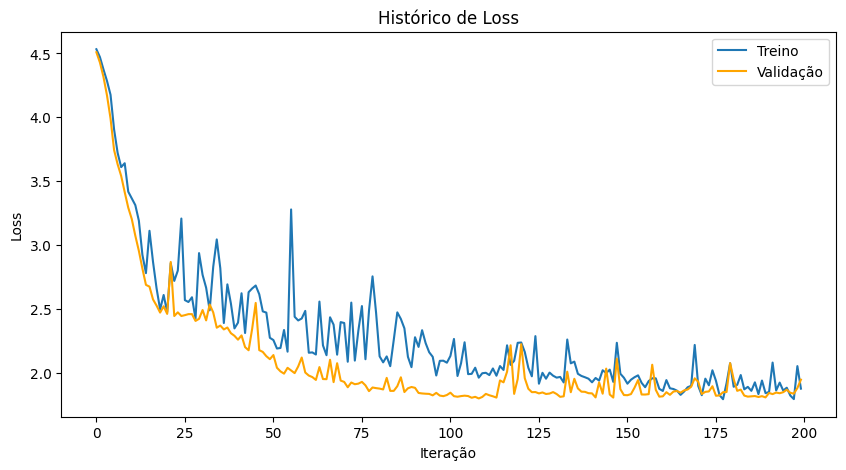

In [99]:
stream = DataStream()
model  = AutoFormerModel(stream)

loss_history = {"train": [], "val": [], "epoca": [], "lote": []}
clear_output(wait=True)    
model.Treinar(200, LossLog) 